In [4]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("ARTICULOS_LANGSMITH")
os.environ["LANGCHAIN_PROJECT"] = "Autores de articulos"
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")

In [5]:
from typing import List, Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

### Retriever

This is the retriever that extracts info from a PDF. Since in this item the author appears as "Student: Facciolo, Ignacio Gabriel" and "Director: Casas, Adrián", the model considered BOTH as authors. The prompt could be changed to NOT consider the director.

With this retriever that extracts info from the item view, the author extraction worked well because it is clearer and the only one that appears.

In [6]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Load PDF from web
url = "https://sedici.unlp.edu.ar/bitstream/handle/10915/87013/Documento_completo.pdf-PDFA.pdf?sequence=1&isAllowed=y"
loader = PyMuPDFLoader(url)
all_docs = loader.load()

target_docs = all_docs[:2]

# Splitter - Increase chunk_size
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200)
doc_splits = text_splitter.split_documents(target_docs)

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

vectorstore = Chroma.from_documents(
    documents=doc_splits,
    embedding=embeddings,
    collection_name="sedici-rag"
)

# Fetch more context chunks
retriever_pdf = vectorstore.as_retriever(search_kwargs={"k": 5})

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10944.29it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10944.29it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader

# Load web page content
url = "https://sedici.unlp.edu.ar/handle/10915/87013"
loader = WebBaseLoader(url)
doc = loader.load()

# Splitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200)
doc_splits = text_splitter.split_documents(doc)

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

vectorstore = Chroma.from_documents(
    documents=doc_splits,
    embedding=embeddings,
    collection_name="sedici-rag-2"
)

# Fetch more context chunks
retriever_web = vectorstore.as_retriever(search_kwargs={"k": 5})

USER_AGENT environment variable not set, consider setting it to identify your requests.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10740.10it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10740.10it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### LLMs

#### Name Extractor

In [8]:
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate


# Data model
class ExtractNameDocuments(BaseModel):
    """List of author names extracted from the document."""

    author_names: list[str] = Field(
        description="A list of strings, where each string is the name of an author found in the document. For example: ['John Doe', 'Jane Smith']. If no author names are found, return an empty list."
    )

name_extraction_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """You are an information extraction assistant. 
         Extract only the author names from the following document. 
         Do NOT include Directors, supervisors, or any other names mentioned in the document unless they are explicitly identified as authors.
         If there are multiple authors, separate them with commas."""),
        ("human", "Document: \n\n {document}"),
    ]
)


llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
# Extractor with structured output instead of free text
structured_name_extractor = llm.with_structured_output(ExtractNameDocuments)

# Model with structured output
name_extractor = name_extraction_prompt | structured_name_extractor 


#### Topic detector

In [9]:
possible_topics = ["Physical Education", "Health", "Math Education", "Chemistry", "Computer Science", "Biology Education", "Social Science Education", "Language and Literature Education", "Artistic Education"]

class ExtractTopicDocument(BaseModel):
    """Topic extracted from the document's abstract."""
    topic: str = Field(
        description=f"The topic of the document based on its abstract. Must be one of the following: {possible_topics}. If the topic cannot be determined, return 'Unknown'."
    )

topic_extractor = ChatPromptTemplate.from_messages(
    [
        ("system", f"""You are an information extraction assistant. Extract the topic of the document based on its abstract.
         The topic must be one of the list provided: {possible_topics}. If the topic cannot be determined, return 'Unknown'."""),
        ("human", "Document abstract: \n\n {abstract}"),
    ]
) | llm.with_structured_output(ExtractTopicDocument)

question = "What is the article summary?"
docs = retriever_web.invoke(question)
doc_txt = docs[0].page_content
print("Extracted topic:", topic_extractor.invoke({"abstract": doc_txt}).topic)

Extracted topic: Physical Education


#### Abstract Extractor without RAG

In [10]:
from langchain_community.document_loaders import WebBaseLoader, PyMuPDFLoader

class ExtractAbstractDocument(BaseModel):
    """Abstract extracted from the document."""
    abstract: str = Field(
        description=f"The abstract of the document. If no abstract is found, return 'Unknown'."
    )

abstract_extractor = ChatPromptTemplate.from_messages(
    [
        ("system", "You are an information extraction assistant. Extract the abstract of the document. If no abstract is found, return 'Unknown'."),
        ("human", "Document: \n\n {document}"),
    ]
) | llm.with_structured_output(ExtractAbstractDocument)

# Get full web page text (without RAG)
url_web = "https://sedici.unlp.edu.ar/handle/10915/87013"
loader_web = WebBaseLoader(url_web)
doc_web = loader_web.load()
full_web_text = doc_web[0].page_content

print("Abstract:", abstract_extractor.invoke({"document": full_web_text}).abstract)

Abstract: El presente ensayo tuvo como objetivo conocer cuáles fueron los efectos de un periodo de entrenamiento sobre la aptitud física de un conjunto de adultos mayores institucionalizados que tenían el síndrome de fragilidad adquirido. Se clasifico a los sujetos como frágiles/no frágiles siguiendo los criterios de clasificación desarrollados por Linda Fried. Ocho adultos mayores participaron del ensayo. Se realizó una batería de test funcionales previo al periodo de entrenamiento, los test fueron el “chair stand test”, test “TUG” y test 5 metros marcha. El periodo de entrenamiento se desarrolló durante un mes, con dos estímulos semanales de una hora, utilizando como método de entrenamiento a la gimnasia multicomponente. Los ejercicios realizados  ombinaron las capacidades condicionales con los componentes de la aptitud física. Se realizaron ejercicios de marcha con cambios de dirección, ejercicios de fuerza con equilibrio y marcha, ejercicios de coordinación combinados con el equili

#### Page Text Extractor

In [11]:
from langchain_core.tools import tool
from langchain.agents import create_agent

def extract_web(url_web: str) -> str:
    # Get full web page text (without RAG)
    loader_web = WebBaseLoader(url_web)
    doc_web = loader_web.load()
    full_web_text = doc_web[0].page_content

    return full_web_text


def extract_pdf(document: str) -> str:
    # Get full PDF text (without RAG)
    loader_pdf = PyMuPDFLoader(document)

    first_pages = []
    # lazy_load allows iterating page by page
    for i, doc in enumerate(loader_pdf.lazy_load()):
        if i >= 2: # Stop after page 2 (index 0, 1)
            break
        first_pages.append(doc)

    return first_pages


### Graph

#### Define Graph State

In [12]:
from typing_extensions import TypedDict
from typing import Optional, List, Annotated
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    url: str
    pdf_url: Optional[str]
    web_error: bool  # <-- We add web_error to the main state
    # Extracted data
    extracted_text: Optional[str]
    authors: List[str]
    topic: str
    abstract: str
    # Message history
    messages: Annotated[list, add_messages]

In [13]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# Web text extraction node
def extract_web_node(state: AgentState):
    """
    Extracts text from the web and proactively searches for the PDF link in case subsequent nodes need it.
    """
    url = state["url"]
    print(f"Analyzing URL: {url}")
    
    try:
        extracted_text = extract_web(url)

        return {
            "extracted_text": extracted_text,
            "pdf_url": False,
            "web_error": False
        }
        
    except Exception as e:
        print(f"[Web Extractor] Error accessing the web: {e}")
        return {
            "web_error": True,
            "extracted_text": None,
            "pdf_url": None
        }

def extract_pdf_node(state: AgentState):
    url = state["url"]
    loader_pdf = PyMuPDFLoader(url)
    doc_pdf = loader_pdf.load()
    full_pdf_text = doc_pdf[0].page_content
    return {"extracted_text": full_pdf_text, "messages": [("assistant", "I have extracted the full text from the PDF.")]}

# Abstract Extraction Node
def extract_abstract_node(state: AgentState):
    extracted_text = state["extracted_text"]
    response = abstract_extractor.invoke({"document": extracted_text})
      
    return {"abstract": response.abstract, "messages": [("assistant", f"I have extracted the abstract: {response.abstract}")]}

# Author Extraction Node
def extraction_authors_node(state: AgentState):
    article_text = state["extracted_text"]
    response = name_extractor.invoke({"document": article_text})
    
    names = response.author_names
    return {"authors": names, "messages": [("assistant", f"I have extracted: {', '.join(names)}")]}

# Topic Extraction Node
def extract_topic_node(state: AgentState):
    abstract = state["abstract"]
    response = topic_extractor.invoke({"abstract": abstract})
    
    topic = response.topic
    return {"topic": topic, "messages": [("assistant", f"I have extracted the topic: {topic}")]}

def ask_human_node(state: AgentState):
    """
    This node executes just after the human resumes the graph.
    Its function is to validate that the state now has the necessary info.
    """
    # Check if the human injected the PDF URL
    pdf_url = state.get("pdf_url")
    
    if not pdf_url:
        print("[Human] No URL was provided.")
    else:
        print(f"[Human] New PDF URL: {pdf_url}")
        
    # No need to return anything new, update_state already modified the state.
    # Optionally, you could return {"web_error": False} to "clean" the error.
    return {"web_error": False}

In [14]:
from typing import Literal

# This function replaces the need for a Supervisor LLM
def router_post_web(state: AgentState):
    """
    Dynamically decides what to do after web_extractor_node finishes.
    """
    if state["web_error"] is True:
        if state["pdf_url"] is None:
            return "ask_human_node"
        else:
            return "extract_pdf_node"
    
    return ["author_extractor_node", "abstract_extractor_node"]

In [15]:
# Graph Construction
workflow = StateGraph(AgentState)

workflow.add_node("web_extractor", extract_web_node)
workflow.add_node("pdf_extractor", extract_pdf_node)
workflow.add_node("author_extractor", extraction_authors_node)
workflow.add_node("abstract_extractor", extract_abstract_node)
workflow.add_node("topic_extractor", extract_topic_node)
workflow.add_node("ask_human_node", ask_human_node)

workflow.add_edge(START, "web_extractor")

workflow.add_conditional_edges("web_extractor", router_post_web, {
    "ask_human_node": "ask_human_node",
    "extract_pdf_node": "pdf_extractor",
    "author_extractor_node": "author_extractor",
    "abstract_extractor_node": "abstract_extractor",
})

workflow.add_edge("ask_human_node", "pdf_extractor")

workflow.add_edge("abstract_extractor", "topic_extractor")

workflow.add_edge("topic_extractor", END)
workflow.add_edge("author_extractor", END)

# Persistence
memory = MemorySaver()
app = workflow.compile(
    checkpointer=memory,
    interrupt_before=["ask_human_node"]
)

In [16]:
config = {"configurable": {"thread_id": "session_1"}}
initial_input = {"url": "https://sedici.unlp.edu.ar/handle/10915/87013"}

# Start Graph
for event in app.stream(initial_input, config):
    for key in event:
        print(f"✅ Node executed: {key}")

# Check if PAUSED waiting for human
state = app.get_state(config)
if state.next and "ask_human_node" in state.next:
    print("⚠️ Web Extractor failed and no PDF was found automatically. ⚠️")
    
    # New url
    new_pdf_url = input("Please enter the direct link to the PDF:\n> ")
    
    app.update_state(config, {"pdf_url": new_pdf_url})
    
    print("\nResuming the graph...")
    
    for event in app.stream(None, config):
         for key in event:
            print(f"✅ Node executed: {key}")

# See final result
final_state = app.get_state(config).values
print("\n--- FINAL RESULT ---")
print(f"Authors: {final_state.get('authors')}")
print(f"Topic: {final_state.get('topic')}")
print(f"Abstract: {final_state.get('abstract')}")

Analyzing URL: https://sedici.unlp.edu.ar/handle/10915/87013
✅ Node executed: web_extractor
✅ Node executed: web_extractor
✅ Node executed: author_extractor
✅ Node executed: abstract_extractor
✅ Node executed: author_extractor
✅ Node executed: abstract_extractor
✅ Node executed: topic_extractor

--- FINAL RESULT ---
Authors: ['Facciolo, Ignacio Gabriel']
Topic: Physical Education
Abstract: El presente ensayo tuvo como objetivo conocer cuáles fueron los efectos de un periodo de entrenamiento sobre la aptitud física de un conjunto de adultos mayores institucionalizados que tenían el síndrome de fragilidad adquirido. Se clasifico a los sujetos como frágiles/no frágiles siguiendo los criterios de clasificación desarrollados por Linda Fried. Ocho adultos mayores participaron del ensayo. Se realizó una batería de test funcionales previo al periodo de entrenamiento, los test fueron el “chair stand test”, test “TUG” y test 5 metros marcha. El periodo de entrenamiento se desarrolló durante un m

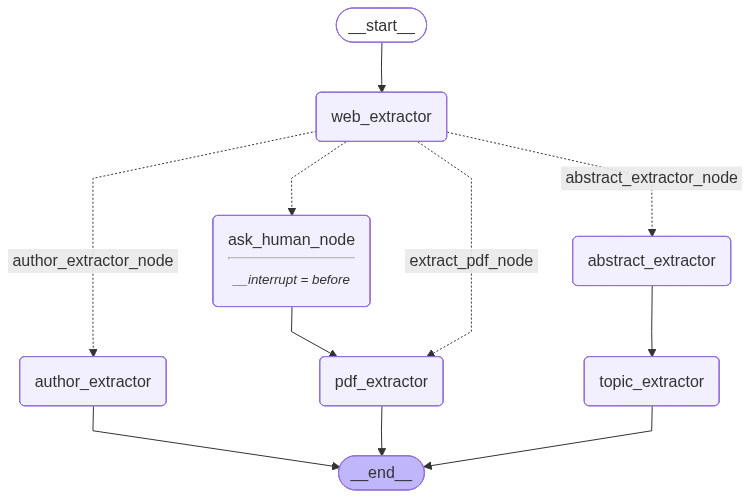

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))